# Final Project: Steam Games Popularity Prediction

https://huggingface.co/datasets/FronkonGames/steam-games-dataset/tree/main

Authors: Autumn Mizer, Steven Thomas, Josiah Reinholz

### Overview

This project determines whether the popularity of Steam games can be predicted using features from the Steam dataset (https://huggingface.co/datasets/FronkonGames/steam-games-dataset/tree/main). The target variable is 'Estimated Owners' treated as the game popularity.

First, statistical analysis was performed using Kruskal-Wallis tests for continuous variables and Chi-Squared tests for categorical, to determine if there are statistically significant differences in the feature distributions across the ownership groups. The main goal with the statistical analysis is to identify which variables are best associated with popularity of a game.

Predictive models were also developed to see how well game popularity can be estimated from the features. Models included are regression approaches like a baseline linear regression model to see linear relationships between the variables, and a random forest regressor to see non linear interactions and also feature dependencies. Also, classification tasks were used, models included are logistic regression and random forest classification to compare performance under a categorical meaning.

### Research Questions

.. more specific but still viable
- What features are best at predicting a games popularity on Steam?
- Do meta critic reviews contribute to a games popularity?
- Does price affect the popularity of a game?
- Can playtime (2 weeks or overtime) suggest the popularity of a game?


### Hypothesis

H0 - There is not a relationship between a games features and its popularity on Steam

HA - There is a relationship between a games features and its popularity on Steam

### Dataset

Brief Summary of Dataset:
// todo dataset summary

In [48]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

df = pd.read_csv('games.csv')

print(df.shape)
df.head()

(122611, 40)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


### Preprocessing

In [49]:
# 1. See all unique owner brackets (the names of the classes)
unique_ranges = df['Estimated owners'].unique()
print("Unique Owner Brackets:")
print(unique_ranges)

# 2. See how many unique options there are (the count of classes)
num_options = df['Estimated owners'].nunique()
print(f"\nTotal number of unique categories: {num_options}")

# 3. See the distribution (how many games are in each bracket)
print("\nGames per category:")
print(df['Estimated owners'].value_counts())

# 4. (Optional) Sort them logically to see the progression
print("\nSorted categories:")
print(sorted(df['Estimated owners'].unique()))

Unique Owner Brackets:
['0 - 0' '0 - 20000' '100000 - 200000' '500000 - 1000000' '20000 - 50000'
 '200000 - 500000' '50000 - 100000' '2000000 - 5000000'
 '10000000 - 20000000' '1000000 - 2000000' '20000000 - 50000000'
 '5000000 - 10000000' '100000000 - 200000000' '50000000 - 100000000']

Total number of unique categories: 14

Games per category:
Estimated owners
0 - 20000                75404
0 - 0                    21641
20000 - 50000            11396
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2853
500000 - 1000000          1154
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

Sorted categories:
['0 - 0', '0 - 20000', '100000 - 200000', '1000000 - 2000000', '10000000 - 20000000', '100000000 - 200000000', '20000 - 50000', '200000 - 500000', '2000000

In [50]:
def preprocess_steam_data(df):
    # 1. CLEAN TARGET VARIABLE (Estimated Owners)
    owner_map = {
        "0 - 0": 0,
        "0 - 20000": 1,
        "20000 - 50000": 2,
        "50000 - 100000": 3,
        "100000 - 200000": 4,
        "200000 - 500000": 5,
        "500000 - 1000000": 6,
        "1000000 - 2000000": 7,
        "2000000 - 5000000": 8,
        "5000000 - 10000000": 9,
        "10000000 - 20000000": 10,
        "20000000 - 50000000": 11,
        "50000000 - 100000000": 12,
        "100000000 - 200000000": 13,
    }
    df['target'] = df['Estimated owners'].map(owner_map)
    
    # 2. DATE ENGINEERING
    # Convert 'Aug 1, 2023' format to datetime
    df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
    # Calculate days since release (relative to "today" in 2026)
    reference_date = pd.to_datetime('2026-04-30')
    df['Days_Since_Release'] = (reference_date - df['Release date']).dt.days.fillna(0)

    # 3. NUMERIC FEATURES & RATIOS
    # Create a success ratio (Positive reviews vs Total)
    df['Total_Reviews'] = df['Positive'] + df['Negative']
    df['Positive_Ratio'] = df['Positive'] / df['Total_Reviews']
    df['Positive_Ratio'] = df['Positive_Ratio'].fillna(0) # Handle games with 0 reviews
    df['Negative_Ratio'] = df['Negative'] / df['Total_Reviews']
    df['Negative_Ratio'] = df['Negative_Ratio'].fillna(0)
    
    # 4. BINARY ENCODING (True/False to 1/0)
    for col in ['Windows', 'Mac', 'Linux']:
        df[col] = df[col].astype(int)

    # 5. MULTI-LABEL ENCODING (Genres & Tags)
    # These columns are strings like "Action,Adventure,RPG"
    def split_and_clean(x):
        if pd.isna(x) or x == "": return []
        return [i.strip() for i in str(x).split(',')]

    mlb = MultiLabelBinarizer()
    
    # Process Genres
    genre_series = df['Genres'].apply(split_and_clean)
    genre_encoded = mlb.fit_transform(genre_series)
    genre_df = pd.DataFrame(genre_encoded, columns=[f"Genre_{c}" for c in mlb.classes_])
    
    # 6. Convert Text to Length
    df['About_Length'] = df['About the game'].str.len().fillna(0)

    # 7. FINAL ASSEMBLY
    # Drop high-cardinality/text columns that aren't useful for basic classification
    cols_to_drop = [
        'AppID', 'Name', 'Estimated owners', 'Release date', 'About the game', 
        'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 
        'Website', 'Support url', 'Support email', 'Metacritic url', 'Developers', 
        'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies', 'Notes'
    ]
    
    df_final = df.drop(columns=cols_to_drop)
    df_final = pd.concat([df_final, genre_df], axis=1)
    
    return df_final

In [51]:
df_clean = preprocess_steam_data(df)
df_clean.head()

,Peak CCU,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,...,Genre_Short,Genre_Simulation,Genre_Software Training,Genre_Sports,Genre_Strategy,Genre_Tutorial,Genre_Utilities,Genre_Video Production,Genre_Violent,Genre_Web Publishing
0,0,0,0.00,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,5.24,65,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,4.99,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,8.99,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,4.99,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
numeric_cols = [
    "Price", "Peak CCU", "Positive_Ratio", "Negative_Ratio", "Days_Since_Release",
    "Metacritic score", "Recommendations", "Average playtime forever",
    "Achievements", "Required age", "About_Length"
]
scaler = StandardScaler()
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

df_clean.head()

,Peak CCU,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,...,Genre_Short,Genre_Simulation,Genre_Software Training,Genre_Sports,Genre_Strategy,Genre_Tutorial,Genre_Utilities,Genre_Video Production,Genre_Violent,Genre_Web Publishing
0,-0.014638,-0.101362,-0.380265,0,0,1,0,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0
1,-0.014638,-0.101362,0.037899,65,0,1,0,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.014638,-0.101362,0.017948,0,0,1,1,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.014370,-0.101362,0.337157,0,1,1,0,0,-0.187763,0,...,0,1,0,0,0,0,0,0,0,0
4,-0.014638,-0.101362,0.017948,0,0,1,0,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0


### Statistical Analysis

In [53]:
import numpy as np
from scipy.stats import kruskal

kruskal_results = []

for var in numeric_cols:
    x = df_clean[var].values
    y = df_clean['target'].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    data_x = x[mask]
    data_y = y[mask]

    samples_by_group = []
    for value in set(data_y):
        samples_by_group.append(data_x[data_y == value])

    stat, p = kruskal(*samples_by_group)
    n = len(data_x)
    k = len(set(data_y))
    epsilon_sq = (stat - k + 1) / (n - k)   # epsilon-squared effect size

    kruskal_results.append({
        'variable': var,
        'test': 'Kruskal-Wallis',
        'statistic': stat,
        'p_value': p,
        'epsilon_squared': epsilon_sq
    })

pd.DataFrame(kruskal_results)

,variable,test,statistic,p_value,epsilon_squared
0,Price,Kruskal-Wallis,23605.983484,0.0,0.192443
1,Peak CCU,Kruskal-Wallis,39408.488066,0.0,0.321341
2,Positive_Ratio,Kruskal-Wallis,37980.622700,0.0,0.309695
3,Negative_Ratio,Kruskal-Wallis,31268.053773,0.0,0.254941
4,Days_Since_Release,Kruskal-Wallis,27477.850199,0.0,0.224025
5,Metacritic score,Kruskal-Wallis,25043.051672,0.0,0.204165
6,Recommendations,Kruskal-Wallis,43883.956913,0.0,0.357847
7,Average playtime forever,Kruskal-Wallis,47821.903344,0.0,0.389968
8,Achievements,Kruskal-Wallis,9452.717215,0.0,0.076998
9,Required age,Kruskal-Wallis,9261.869696,0.0,0.075441


In [54]:
from scipy.stats import chi2_contingency

categorical_variables = ["Windows", "Mac", "Linux"] + [col for col in df_clean.columns if col.startswith("Genre_")]

alpha = 0.05
bonferroni_alpha = alpha / len(categorical_variables)

chi2_results = []

for var in categorical_variables:
    x = df_clean[var].astype(float).values
    y = df_clean["target"].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    data_x = x[mask]
    data_y = y[mask]

    ct = pd.crosstab(data_y, data_x)
    chi2_stat, p, dof, expected = chi2_contingency(ct)

    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2_stat / (n * min_dim))

    chi2_results.append({
        'variable': var,
        'test': 'Chi-Squared',
        'statistic': chi2_stat,
        'p_value': p,
        'significant (Bonferroni)': p < bonferroni_alpha
    })

pd.DataFrame(chi2_results)

,variable,test,statistic,p_value,significant (Bonferroni)
0,Windows,Chi-Squared,4.967473,9.759022e-01,False
1,Mac,Chi-Squared,2806.510131,0.000000e+00,True
2,Linux,Chi-Squared,1401.685027,6.653857e-292,True
3,Genre_360 Video,Chi-Squared,0.626059,9.999998e-01,False
4,Genre_Accounting,Chi-Squared,6.322454,9.336260e-01,False
5,Genre_Action,Chi-Squared,2994.559909,0.000000e+00,True
6,Genre_Adventure,Chi-Squared,2619.962796,0.000000e+00,True
7,Genre_Animation & Modeling,Chi-Squared,31.373303,2.972474e-03,False
8,Genre_Audio Production,Chi-Squared,23.518141,3.586280e-02,False
9,Genre_Casual,Chi-Squared,3245.716227,0.000000e+00,True


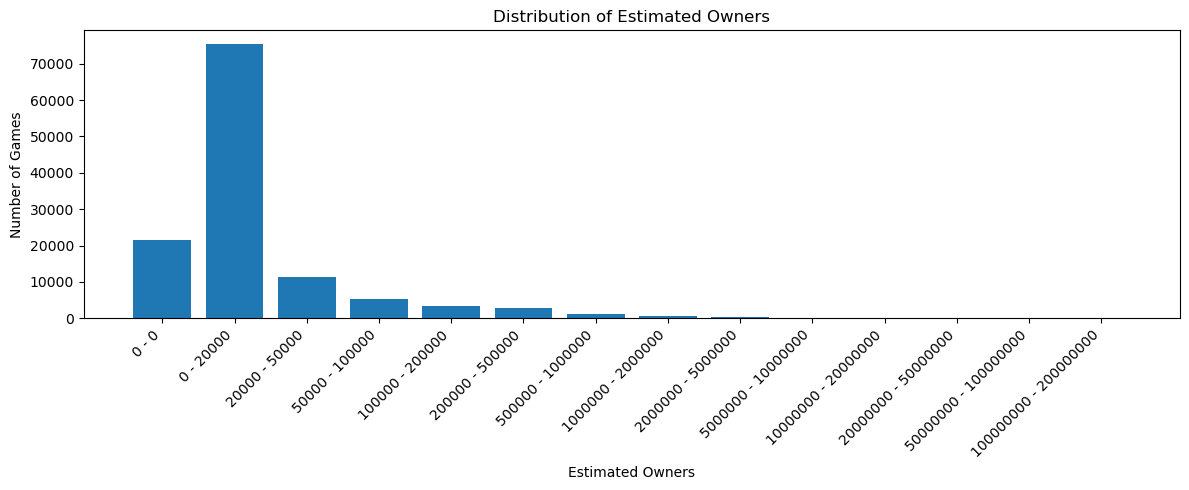

In [55]:
import matplotlib.pyplot as plt

owner_order = [
    "0 - 0", "0 - 20000", "20000 - 50000", "50000 - 100000",
    "100000 - 200000", "200000 - 500000", "500000 - 1000000",
    "1000000 - 2000000", "2000000 - 5000000", "5000000 - 10000000",
    "10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000",
    "100000000 - 200000000"
]

counts = df["Estimated owners"].value_counts().reindex(owner_order)

plt.figure(figsize=(12, 5))
plt.bar(owner_order, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Estimated Owners")
plt.ylabel("Number of Games")
plt.title("Distribution of Estimated Owners")
plt.tight_layout()
plt.show()

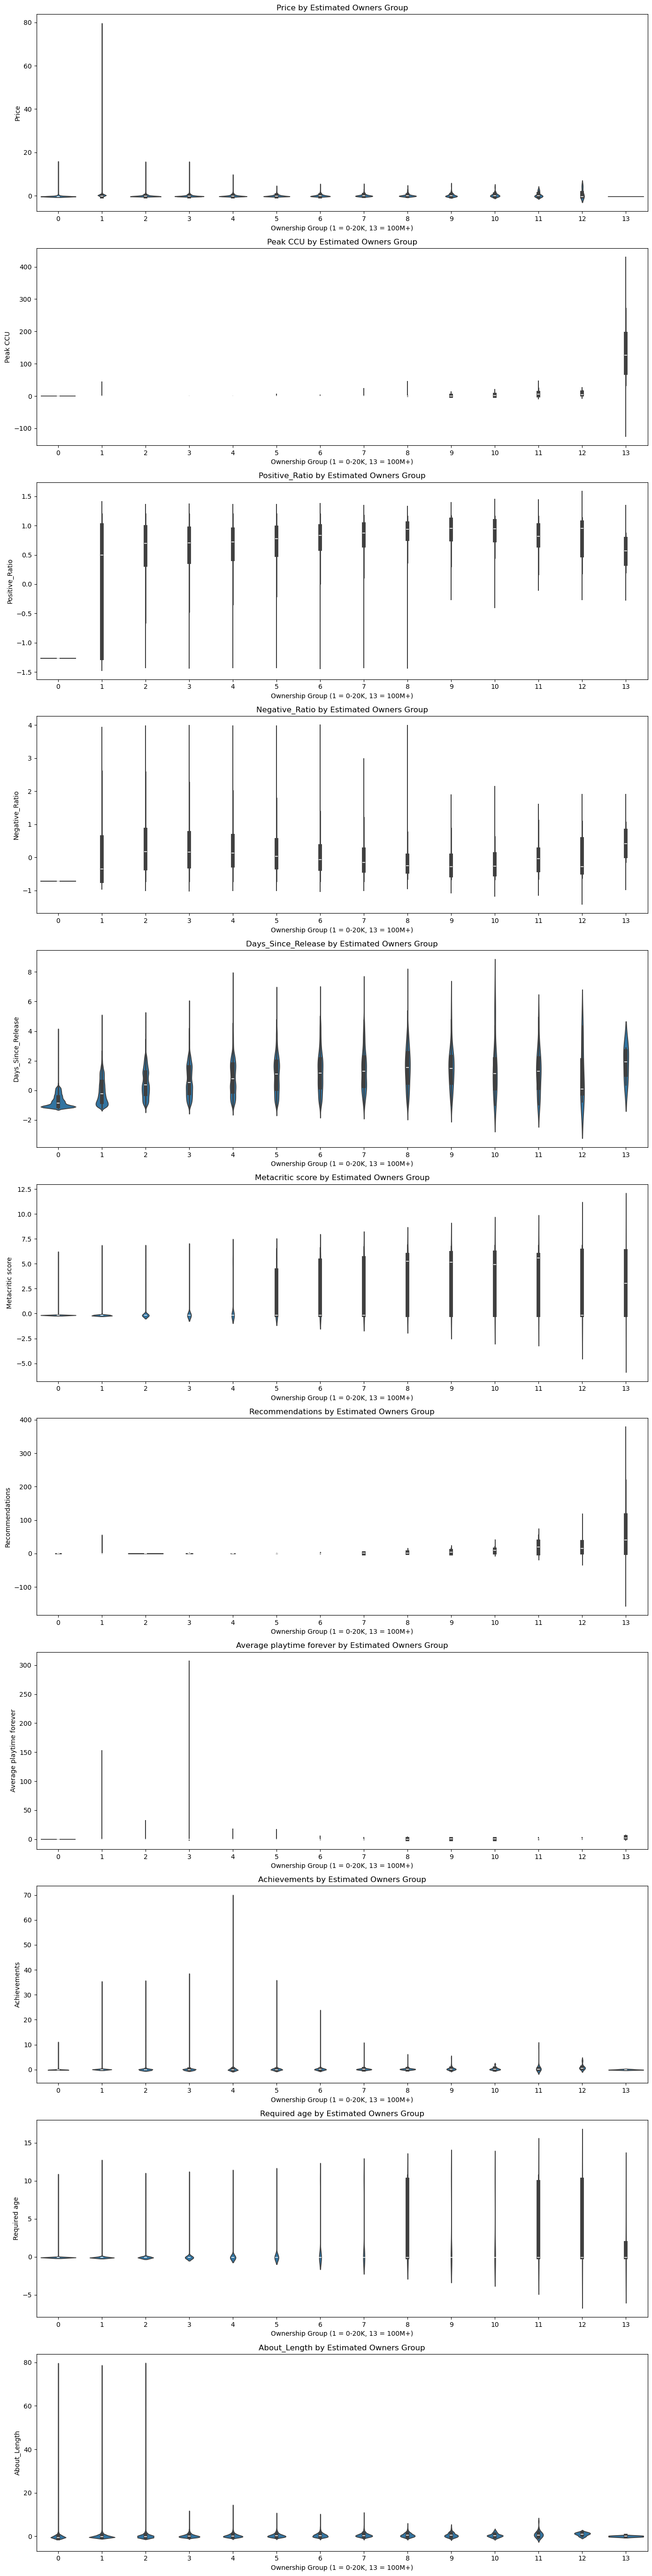

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt



fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(14, 5 * len(numeric_cols)))

for i, var in enumerate(numeric_cols):
    sns.violinplot(data=df_clean, x="target", y=var, ax=axes[i])
    axes[i].set_title(f"{var} by Estimated Owners Group")
    axes[i].set_xlabel("Ownership Group (1 = 0-20K, 13 = 100M+)")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

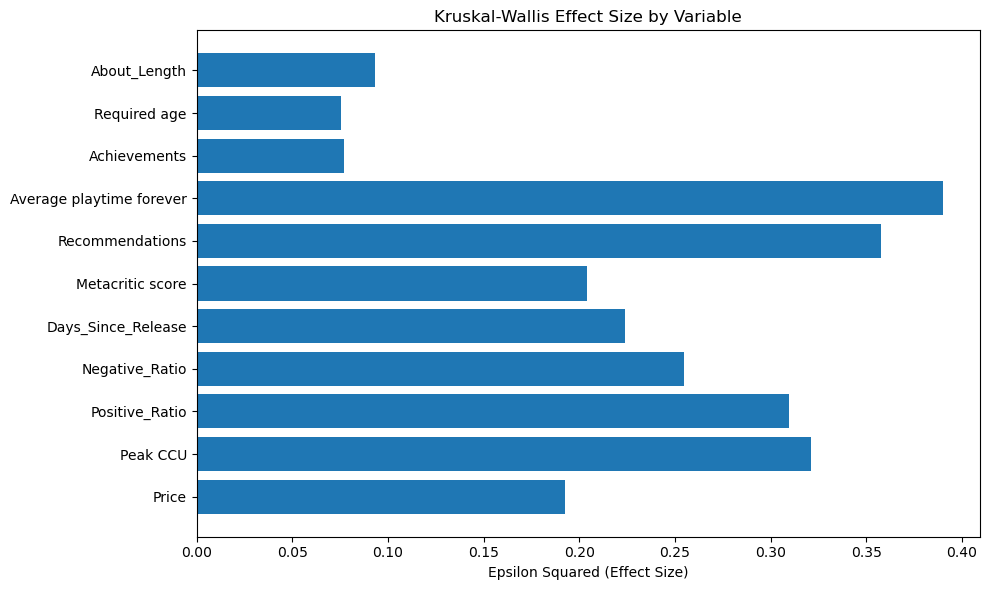

In [57]:
import matplotlib.pyplot as plt

variables = [r['variable'] for r in kruskal_results]
epsilon_values = [r['epsilon_squared'] for r in kruskal_results]

plt.figure(figsize=(10, 6))
bars = plt.barh(variables, epsilon_values)
plt.xlabel('Epsilon Squared (Effect Size)')
plt.title('Kruskal-Wallis Effect Size by Variable')
plt.tight_layout()
plt.show()

### Regression

The code segment below handles NaNs by filling with the median of that column, preventing bias from dropping rows. Also, the target variable is defined nad so is the feature set.

In [58]:
# fill NaNs with median
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# target
y = df_clean["target"]

# features
X = df_clean.drop(columns=["target"])

The code segment below splits the data into training and testing sets with an 80/20 split.

In [59]:
from sklearn.model_selection import train_test_split

# split up into train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The code segment below trains a linear regression model as the baseline, assuming a linear relationship between the target and the features

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
 
# baseline model
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# partially linear, model missing complex relationships
print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Linear Regression R^2: {r2_lr}")

Linear Regression RMSE: 0.975711092778527
Linear Regression R^2: 0.4334675027102435


The code segment below extracts coefficients from the model to see how each feature affects predictions. Positive = increase in popularity, Negative = decrease in popularity

In [61]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

# unstable coefs due to multicollinearity
print(coef_df)

                        feature  coefficient
41                  Genre_Movie     2.646709
12                   Score rank    -0.799136
15     Average playtime forever     0.610486
24              Genre_360 Video    -0.533306
47                  Genre_Short    -0.533306
52               Genre_Tutorial    -0.533306
35               Genre_Episodic    -0.533306
32            Genre_Documentary    -0.533306
55                Genre_Violent    -0.515427
46         Genre_Sexual Content    -0.472027
0                      Peak CCU    -0.412476
56         Genre_Web Publishing     0.385137
40  Genre_Massively Multiplayer     0.374393
21               Positive_Ratio     0.333560
8              Metacritic score     0.318347
19           Days_Since_Release     0.265520
34              Genre_Education    -0.211522
29       Genre_Audio Production    -0.192847
5                       Windows     0.168279
44                    Genre_RPG     0.153845
36           Genre_Free To Play     0.136737
31  Genre_

The code segment below plots the LR model predicted vs actual for popularity

Text(0.5, 1.0, 'Linear Regression: Predicted vs Actual')

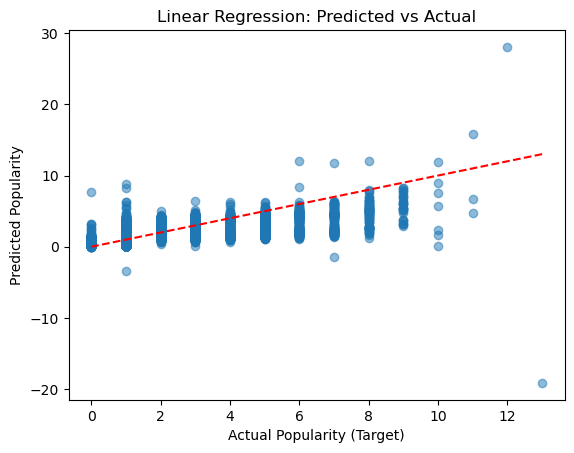

In [62]:
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Popularity (Target)")
plt.ylabel("Predicted Popularity")
plt.title("Linear Regression: Predicted vs Actual")

The code segment below is a residual analysis vs the actual

Text(0.5, 1.0, 'Residuals vs Actual (Linear Regression)')

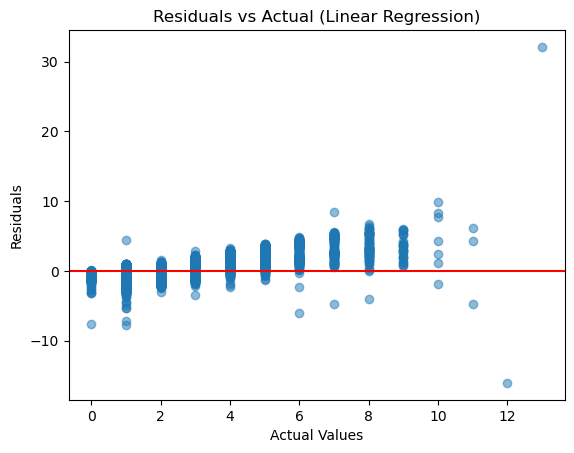

In [63]:
residuals = y_test - y_pred_lr

plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual (Linear Regression)")

The code segment below is training of a random forest regressor model to capture non linear relationships and interactions between the features.

In [64]:
from sklearn.ensemble import RandomForestRegressor

# random forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# higher R^2 and lower RMSE than linear regression, captures non-linear relationships
print(f"Random Forest RMSE: {rmse_rf}")
print(f"Random Forest R^2: {r2_rf}")

Random Forest RMSE: 0.5573522589839786
Random Forest R^2: 0.8151404577794196


The code segment below shows the feature importance scores

In [65]:
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_ * 100
}).sort_values(by='importance', ascending=False)

print(feature_importances)

                        feature  importance
20                Total_Reviews   63.190118
11                     Negative   14.275607
19           Days_Since_Release    4.602331
2                         Price    3.942155
23                 About_Length    2.510703
10                     Positive    1.300600
13                 Achievements    1.130446
14              Recommendations    1.118554
3                      Discount    0.920628
17      Median playtime forever    0.854227
15     Average playtime forever    0.811586
22               Negative_Ratio    0.684996
21               Positive_Ratio    0.684806
0                      Peak CCU    0.657057
4                     DLC count    0.326404
26                 Genre_Action    0.253852
27              Genre_Adventure    0.252113
51               Genre_Strategy    0.250911
39                  Genre_Indie    0.249423
30                 Genre_Casual    0.220365
48             Genre_Simulation    0.209935
8              Metacritic score 

Text(0.5, 1.0, 'Top 15 Feature Importances RF')

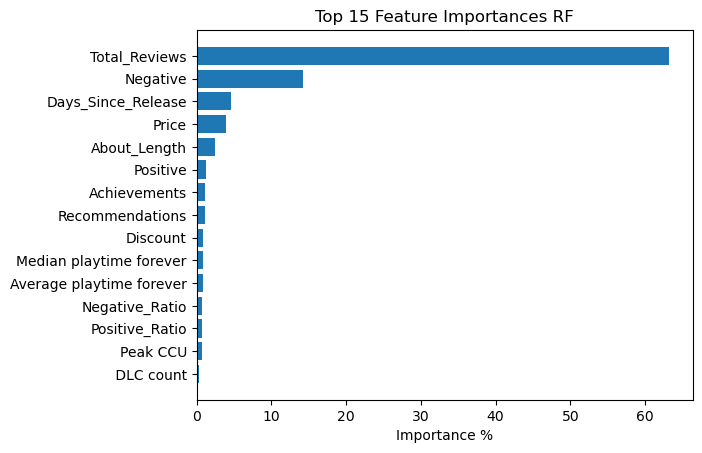

In [67]:
fi = feature_importances.copy()
fi["importance"] = fi["importance"] / fi["importance"].sum() * 100

plt.barh(fi["feature"][:15][::-1], fi["importance"][:15][::-1])
plt.xlabel("Importance %")
plt.title("Top 15 Feature Importances RF")

The code segment below plots the predicted vs actual popularities for the RF model

Text(0.5, 1.0, 'Random Forest: Predicted vs Actual')

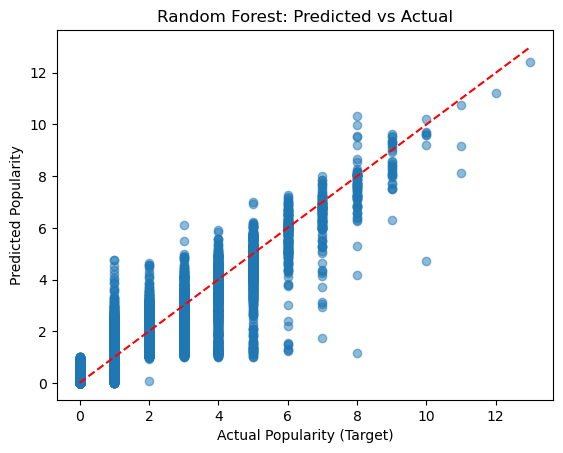

In [68]:
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Popularity (Target)")
plt.ylabel("Predicted Popularity")
plt.title("Random Forest: Predicted vs Actual")

Model comparison of the baseline LR model and the random forest model between the RMSE and R^2

In [ ]:
print('Linear Regression vs Random Forest\n')
print('Model: Linear Regression')
print(f'RMSE: {rmse_lr}, R^2: {r2_lr}\n')
print('Model: Random Forest')
print(f'RMSE: {rmse_rf}, R^2: {r2_rf}')

Linear Regression vs Random Forest

Model: Linear Regression
RMSE: 0.975711092778527, R^2: 0.4334675027102435

Model: Random Forest
RMSE: 0.5573522589839786, R^2: 0.8151404577794196
